In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
from sklearn.model_selection import KFold
import random


/home/fnst/Desktop/shendi/whisper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## iemoloading

In [4]:
df = pd.read_excel('iemocap_emotions.xlsx', index_col=0)

In [5]:
df

,name,emotion,type,gender,start,end,V,A,D
0,Ses01F_impro01_F000,neu,improvised,f,6.2901,8.2357,2.5,2.5,2.5
1,Ses01F_impro01_F001,neu,improvised,f,10.0100,11.3925,2.5,2.5,2.5
2,Ses01F_impro01_F002,neu,improvised,f,14.8872,18.0175,2.5,2.5,2.5
3,Ses01F_impro01_F003,xxx,improvised,f,19.2900,20.7875,2.5,3.0,3.0
4,Ses01F_impro01_F004,xxx,improvised,f,21.3257,24.7400,2.5,3.0,2.5
...,...,...,...,...,...,...,...,...,...
10034,Ses05M_script03_2_M041,ang,scripted,m,236.5700,244.8300,1.0,4.5,5.0
10035,Ses05M_script03_2_M042,ang,scripted,m,244.8400,246.5800,1.0,4.5,4.5
10036,Ses05M_script03_2_M043,ang,scripted,m,246.5900,248.8300,1.5,4.0,4.5
10037,Ses05M_script03_2_M044,ang,scripted,m,255.8600,260.3300,1.0,5.0,5.0


In [6]:
df_cleaned = df[df['emotion'].isin(['ang', 'neu', 'hap', 'sad', 'exc'])]

In [7]:
df_cleaned

,name,emotion,type,gender,start,end,V,A,D
0,Ses01F_impro01_F000,neu,improvised,f,6.2901,8.2357,2.5,2.5,2.5
1,Ses01F_impro01_F001,neu,improvised,f,10.0100,11.3925,2.5,2.5,2.5
2,Ses01F_impro01_F002,neu,improvised,f,14.8872,18.0175,2.5,2.5,2.5
5,Ses01F_impro01_F005,neu,improvised,f,27.4600,31.4900,2.5,3.5,2.0
12,Ses01F_impro01_F012,ang,improvised,f,85.2700,88.0200,2.0,3.5,3.5
...,...,...,...,...,...,...,...,...,...
10034,Ses05M_script03_2_M041,ang,scripted,m,236.5700,244.8300,1.0,4.5,5.0
10035,Ses05M_script03_2_M042,ang,scripted,m,244.8400,246.5800,1.0,4.5,4.5
10036,Ses05M_script03_2_M043,ang,scripted,m,246.5900,248.8300,1.5,4.0,4.5
10037,Ses05M_script03_2_M044,ang,scripted,m,255.8600,260.3300,1.0,5.0,5.0


In [8]:
reset_seed(42)

whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_tiny')
emo2num = {
    'hap' : 0,
    'neu' : 1,
    'sad' : 2,
    'ang' : 3,
    'exc' : 0
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger'
}

audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []


for root, folders, files in os.walk('samples'):
    for filename in files:
        file_path = os.path.join(root, filename)
        if not filename.startswith('.'):
            title = filename.replace('.wav', '')
            if title in df_cleaned['name'].tolist():
                file_path = os.path.join(root, filename)
                audio_data, sr = librosa.load(file_path, sr=16000)
                
                input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features

                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = df_cleaned[df_cleaned['name'] == title]['emotion'].item()
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [9]:
print(np.unique(np.array(labels), return_counts=True))
print(np.unique(np.array(emotions), return_counts=True))

(array([0, 1, 2, 3]), array([1636, 1708, 1084, 1103]))
(array(['ang', 'exc', 'hap', 'neu', 'sad'], dtype='<U3'), array([1103, 1041,  595, 1708, 1084]))


In [10]:
len(features)

5531

In [11]:
reset_seed(42)
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [12]:
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [13]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 5528 5529 5530]
  Test:  index=[   8   12   15 ... 5515 5524 5525]
Fold 1:
  Train: index=[   0    1    2 ... 5526 5527 5529]
  Test:  index=[  14   19   24 ... 5523 5528 5530]
Fold 2:
  Train: index=[   1    2    3 ... 5528 5529 5530]
  Test:  index=[   0    6    7 ... 5513 5520 5527]
Fold 3:
  Train: index=[   0    3    4 ... 5527 5528 5530]
  Test:  index=[   1    2   10 ... 5522 5526 5529]
Fold 4:
  Train: index=[   0    1    2 ... 5528 5529 5530]
  Test:  index=[   3    4    5 ... 5512 5519 5521]


In [14]:
reset_seed(42)

(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [15]:
reset_seed(42)

trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

In [16]:
reset_seed(42)

class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels)
Fold1test = AudioDataSet(testF1features, testF1labels)

Fold2train = AudioDataSet(trainF2features, trainF2labels)
Fold2test = AudioDataSet(testF2features, testF2labels)

Fold3train = AudioDataSet(trainF3features, trainF3labels)
Fold3test = AudioDataSet(testF3features, testF3labels)

Fold4train = AudioDataSet(trainF4features, trainF4labels)
Fold4test = AudioDataSet(testF4features, testF4labels)

Fold5train = AudioDataSet(trainF5features, trainF5labels)
Fold5test = AudioDataSet(testF5features, testF5labels)



# Example of using DataLoader for batching
train_loaderF1 = DataLoader(Fold1train, batch_size=4, shuffle=True)
val_loaderF1 = DataLoader(Fold1test, batch_size=4, shuffle=False)

train_loaderF2 = DataLoader(Fold2train, batch_size=4, shuffle=True)
val_loaderF2 = DataLoader(Fold2test, batch_size=4, shuffle=False)

train_loaderF3 = DataLoader(Fold3train, batch_size=4, shuffle=True)
val_loaderF3 = DataLoader(Fold3test, batch_size=4, shuffle=False)

train_loaderF4 = DataLoader(Fold4train, batch_size=4, shuffle=True)
val_loaderF4 = DataLoader(Fold4test, batch_size=4, shuffle=False)

train_loaderF5 = DataLoader(Fold5train, batch_size=4, shuffle=True)
val_loaderF5 = DataLoader(Fold5test, batch_size=4, shuffle=False)

In [17]:
loader_lists = [(train_loaderF1, val_loaderF1), (train_loaderF2, val_loaderF2), (train_loaderF3, val_loaderF3), (train_loaderF4, val_loaderF4), (train_loaderF5, val_loaderF5)]

## Train Function for Whisper

In [18]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs).logits
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [19]:
reset_seed(42)
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs).logits
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss} | U_Accuracy: {u_acc} | W_Accuracy: {w_acc} | Precision: {precision} | Recall: {recall} | f1: {f1}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Whisper Tiny

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 23.27 seconds, Training Loss:  1.13, Validation Loss: 0.98, Validation Accuracy:  0.53


Epoch: 2 finished in 23.06 seconds, Training Loss:  0.99, Validation Loss: 0.90, Validation Accuracy:  0.64


Epoch: 3 finished in 23.04 seconds, Training Loss:  0.96, Validation Loss: 0.89, Validation Accuracy:  0.62


Epoch: 4 finished in 23.07 seconds, Training Loss:  0.93, Validation Loss: 0.83, Validation Accuracy:  0.67


...

Epoch: 36 finished in 23.48 seconds, Training Loss:  0.78, Validation Loss: 0.79, Validation Accuracy:  0.67


Epoch: 37 finished in 23.46 seconds, Training Loss:  0.77, Validation Loss: 0.75, Validation Accuracy:  0.69


Epoch: 38 finished in 23.46 seconds, Training Loss:  0.79, Validation Loss: 0.74, Validation Accuracy:  0.71


Epoch: 39 finished in 23.49 seconds, Training Loss:  0.78, Validation Loss: 0.74, Validation Accuracy:  0.70


Epoch: 40 finished in 23.53 seconds, Training Loss:  0.78, Validation Loss: 0.73, Validation Accuracy:  0.70
Each epoch took 23.33 seconds in average.


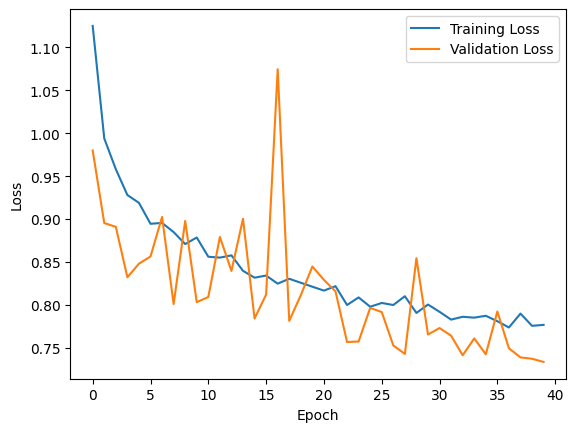

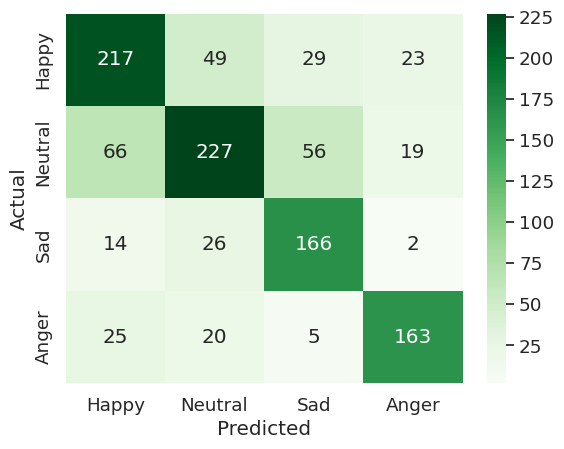

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7334539226999351 | U_Accuracy: 0.7156432255583098 | W_Accuracy: 0.6982836495031617 | Precision: 0.7012940893729158 | Recall: 0.6982836495031617 | f1: 0.6973200008751593
Accuracy per class:
Class 0: 0.6823899371069182
Class 1: 0.6168478260869565
Class 2: 0.7980769230769231
Class 3: 0.7652582159624414


Epoch: 1 finished in 23.42 seconds, Training Loss:  1.13, Validation Loss: 0.97, Validation Accuracy:  0.56


Epoch: 2 finished in 23.38 seconds, Training Loss:  0.99, Validation Loss: 0.93, Validation Accuracy:  0.61


Epoch: 3 finished in 23.44 seconds, Training Loss:  0.95, Validation Loss: 0.88, Validation Accuracy:  0.61


...

Epoch: 36 finished in 23.43 seconds, Training Loss:  0.78, Validation Loss: 0.79, Validation Accuracy:  0.68


Epoch: 37 finished in 23.45 seconds, Training Loss:  0.77, Validation Loss: 0.83, Validation Accuracy:  0.65


Epoch: 38 finished in 23.45 seconds, Training Loss:  0.77, Validation Loss: 0.88, Validation Accuracy:  0.67


Epoch: 39 finished in 23.48 seconds, Training Loss:  0.76, Validation Loss: 0.77, Validation Accuracy:  0.69


Epoch: 40 finished in 23.50 seconds, Training Loss:  0.76, Validation Loss: 0.78, Validation Accuracy:  0.68
Each epoch took 23.46 seconds in average.


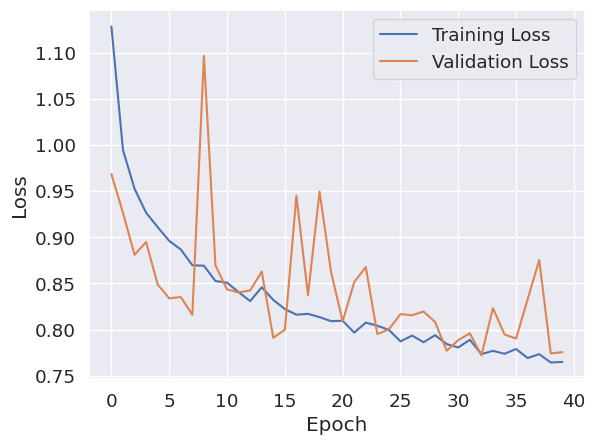

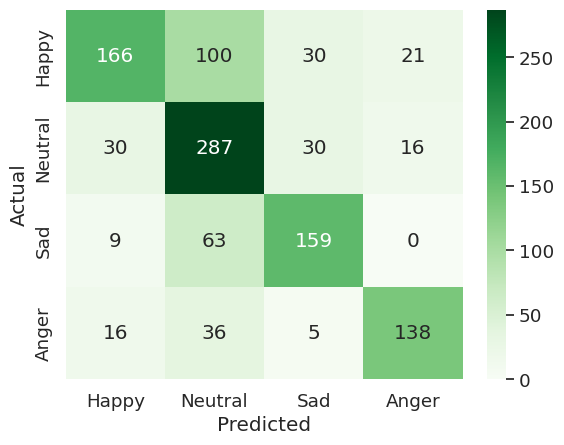

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7721044691245909 | U_Accuracy: 0.6775742277032785 | W_Accuracy: 0.6781193490054249 | Precision: 0.6963950934786263 | Recall: 0.6781193490054249 | f1: 0.6762630432632244
Accuracy per class:
Class 0: 0.5236593059936908
Class 1: 0.790633608815427
Class 2: 0.6883116883116883
Class 3: 0.7076923076923077


Epoch: 1 finished in 23.48 seconds, Training Loss:  1.10, Validation Loss: 1.26, Validation Accuracy:  0.45


Epoch: 2 finished in 23.47 seconds, Training Loss:  0.98, Validation Loss: 0.98, Validation Accuracy:  0.59


Epoch: 3 finished in 23.48 seconds, Training Loss:  0.94, Validation Loss: 1.16, Validation Accuracy:  0.55


...

Epoch: 36 finished in 23.43 seconds, Training Loss:  0.76, Validation Loss: 0.83, Validation Accuracy:  0.67


Epoch: 37 finished in 23.44 seconds, Training Loss:  0.76, Validation Loss: 0.89, Validation Accuracy:  0.63


Epoch: 38 finished in 23.43 seconds, Training Loss:  0.76, Validation Loss: 0.83, Validation Accuracy:  0.66


Epoch: 39 finished in 23.44 seconds, Training Loss:  0.77, Validation Loss: 0.84, Validation Accuracy:  0.64


Epoch: 40 finished in 23.42 seconds, Training Loss:  0.76, Validation Loss: 1.06, Validation Accuracy:  0.57
Each epoch took 23.48 seconds in average.


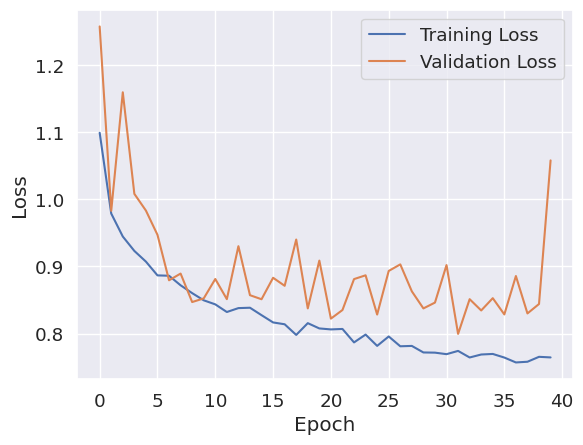

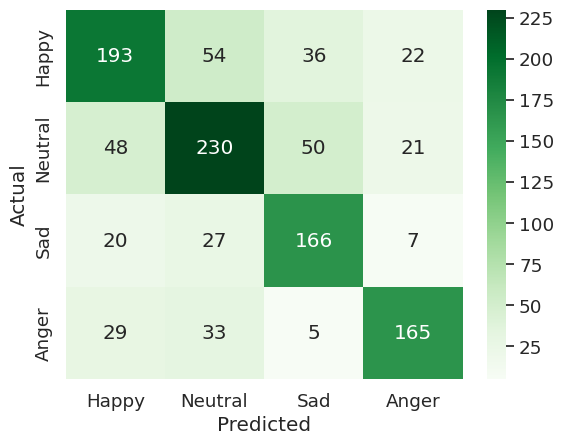

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.7994253413771895 | U_Accuracy: 0.6893912560771741 | W_Accuracy: 0.6817359855334539 | Precision: 0.6839723877211443 | Recall: 0.6817359855334539 | f1: 0.6816671386895454
Accuracy per class:
Class 0: 0.6327868852459017
Class 1: 0.6590257879656161
Class 2: 0.7545454545454545
Class 3: 0.7112068965517241


Epoch: 1 finished in 23.44 seconds, Training Loss:  1.10, Validation Loss: 1.02, Validation Accuracy:  0.51


Epoch: 2 finished in 23.49 seconds, Training Loss:  0.98, Validation Loss: 1.13, Validation Accuracy:  0.50


Epoch: 3 finished in 23.48 seconds, Training Loss:  0.95, Validation Loss: 0.95, Validation Accuracy:  0.62


...

Epoch: 36 finished in 23.50 seconds, Training Loss:  0.77, Validation Loss: 0.87, Validation Accuracy:  0.63


Epoch: 37 finished in 23.49 seconds, Training Loss:  0.76, Validation Loss: 0.87, Validation Accuracy:  0.63


Epoch: 38 finished in 23.48 seconds, Training Loss:  0.76, Validation Loss: 0.80, Validation Accuracy:  0.66


Epoch: 39 finished in 23.48 seconds, Training Loss:  0.76, Validation Loss: 0.79, Validation Accuracy:  0.66


Epoch: 40 finished in 23.47 seconds, Training Loss:  0.76, Validation Loss: 0.80, Validation Accuracy:  0.68
Each epoch took 23.49 seconds in average.


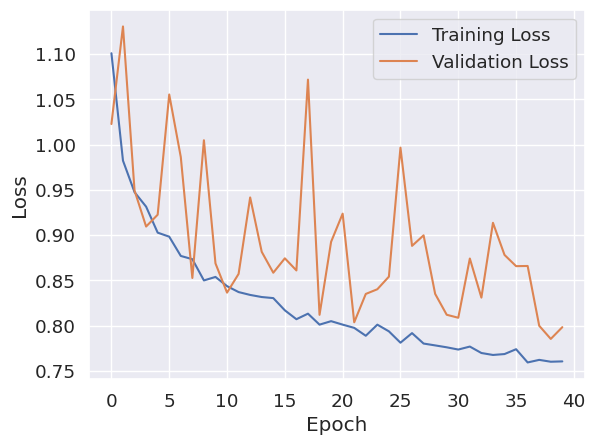

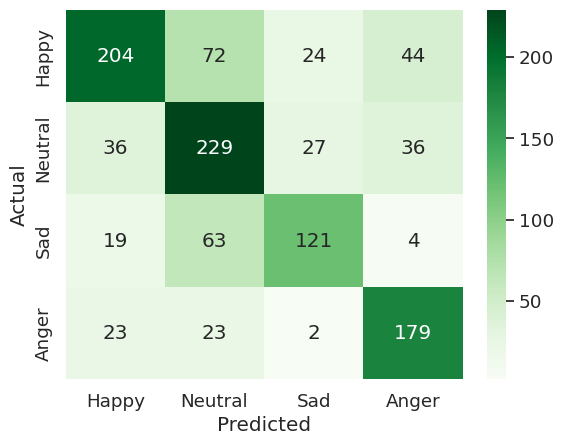

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.785404170913763 | U_Accuracy: 0.6660703264574528 | W_Accuracy: 0.6627486437613019 | Precision: 0.6703302837688331 | Recall: 0.6627486437613019 | f1: 0.6615165134714409
Accuracy per class:
Class 0: 0.5930232558139535
Class 1: 0.698170731707317
Class 2: 0.5845410628019324
Class 3: 0.788546255506608


Epoch: 1 finished in 23.44 seconds, Training Loss:  1.11, Validation Loss: 1.02, Validation Accuracy:  0.55


Epoch: 2 finished in 23.45 seconds, Training Loss:  0.98, Validation Loss: 0.93, Validation Accuracy:  0.61


Epoch: 3 finished in 23.47 seconds, Training Loss:  0.94, Validation Loss: 0.92, Validation Accuracy:  0.61


...

Epoch: 36 finished in 23.45 seconds, Training Loss:  0.76, Validation Loss: 0.84, Validation Accuracy:  0.63


Epoch: 37 finished in 23.40 seconds, Training Loss:  0.76, Validation Loss: 0.87, Validation Accuracy:  0.65


Epoch: 38 finished in 23.45 seconds, Training Loss:  0.75, Validation Loss: 0.84, Validation Accuracy:  0.65


Epoch: 39 finished in 23.43 seconds, Training Loss:  0.74, Validation Loss: 0.88, Validation Accuracy:  0.61


Epoch: 40 finished in 23.46 seconds, Training Loss:  0.74, Validation Loss: 0.82, Validation Accuracy:  0.66
Each epoch took 23.44 seconds in average.


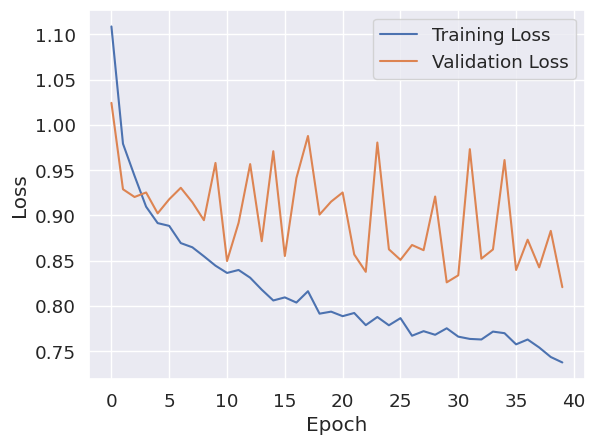

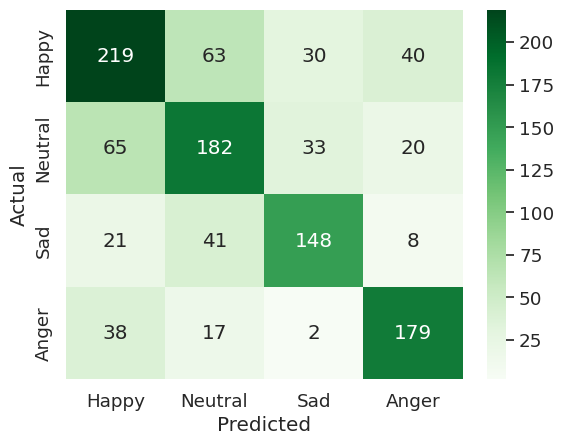

Testing finished with Loss: 0.8207105675759299 | U_Accuracy: 0.6665498541039379 | W_Accuracy: 0.6582278481012658 | Precision: 0.6577277522349358 | Recall: 0.6582278481012658 | f1: 0.657839811380044
Accuracy per class:
Class 0: 0.6221590909090909
Class 1: 0.6066666666666667
Class 2: 0.6788990825688074
Class 3: 0.7584745762711864


In [20]:
reset_seed(42)

for i, (train_loader, val_loader) in enumerate(loader_lists):
    whisper_tiny_path = 'whisper_tiny'
    whisper_tiny = WhisperForAudioClassification.from_pretrained(
        whisper_tiny_path
    )

    for param in whisper_tiny.parameters():
        param.requires_grad = False

    for param in whisper_tiny.projector.parameters():
        param.requires_grad = True

    whisper_tiny.classifier = torch.nn.Linear(256, 4) # Changing the head to fit our data and problem
    whisper_tiny.to(device)

    optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(whisper_tiny, f'iemo_whisper_tiny_shemo_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_tiny.load_state_dict(torch.load(f'iemo_whisper_tiny_shemo_simple_fold{i +1}.bin'))
    test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 155.61 seconds, Training Loss:  1.08, Validation Loss: 1.11, Validation Accuracy:  0.56


Epoch: 2 finished in 155.61 seconds, Training Loss:  0.92, Validation Loss: 1.00, Validation Accuracy:  0.61


Epoch: 3 finished in 155.62 seconds, Training Loss:  0.87, Validation Loss: 0.95, Validation Accuracy:  0.63


Epoch: 4 finished in 155.61 seconds, Training Loss:  0.83, Validation Loss: 0.79, Validation Accuracy:  0.67


...

Epoch: 36 finished in 155.53 seconds, Training Loss:  0.61, Validation Loss: 0.67, Validation Accuracy:  0.74


Epoch: 37 finished in 155.47 seconds, Training Loss:  0.61, Validation Loss: 0.68, Validation Accuracy:  0.73


Epoch: 38 finished in 155.45 seconds, Training Loss:  0.59, Validation Loss: 0.71, Validation Accuracy:  0.72


Epoch: 39 finished in 155.55 seconds, Training Loss:  0.59, Validation Loss: 0.72, Validation Accuracy:  0.73


Epoch: 40 finished in 155.48 seconds, Training Loss:  0.59, Validation Loss: 0.88, Validation Accuracy:  0.68
Each epoch took 155.58 seconds in average.


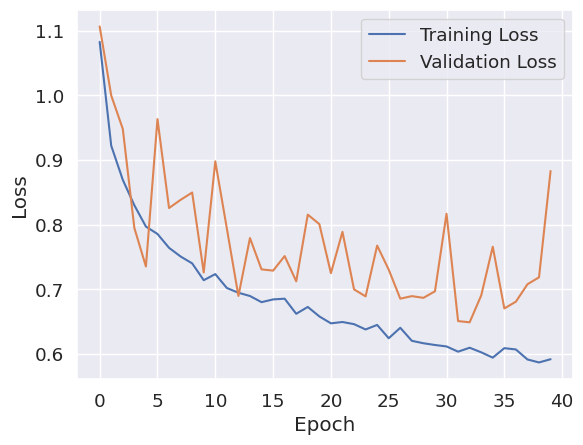

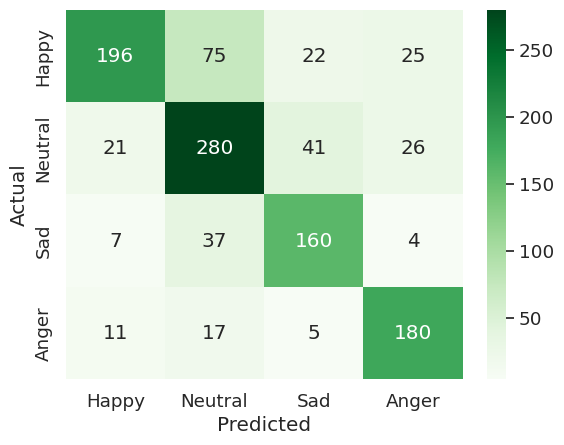

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6491152817981876 | U_Accuracy: 0.7478807395603084 | W_Accuracy: 0.7371273712737128 | Precision: 0.7464055290949472 | Recall: 0.7371273712737128 | f1: 0.7357400284450248
Accuracy per class:
Class 0: 0.6163522012578616
Class 1: 0.7608695652173914
Class 2: 0.7692307692307693
Class 3: 0.8450704225352113


Epoch: 1 finished in 155.42 seconds, Training Loss:  1.07, Validation Loss: 0.87, Validation Accuracy:  0.64


Epoch: 2 finished in 155.50 seconds, Training Loss:  0.91, Validation Loss: 0.94, Validation Accuracy:  0.60


Epoch: 3 finished in 155.48 seconds, Training Loss:  0.84, Validation Loss: 0.86, Validation Accuracy:  0.64


...

Epoch: 36 finished in 155.32 seconds, Training Loss:  0.59, Validation Loss: 0.80, Validation Accuracy:  0.68


Epoch: 37 finished in 155.34 seconds, Training Loss:  0.59, Validation Loss: 0.74, Validation Accuracy:  0.70


Epoch: 38 finished in 155.34 seconds, Training Loss:  0.59, Validation Loss: 0.82, Validation Accuracy:  0.69


Epoch: 39 finished in 155.35 seconds, Training Loss:  0.59, Validation Loss: 0.73, Validation Accuracy:  0.70


Epoch: 40 finished in 155.30 seconds, Training Loss:  0.59, Validation Loss: 0.74, Validation Accuracy:  0.71
Each epoch took 155.45 seconds in average.


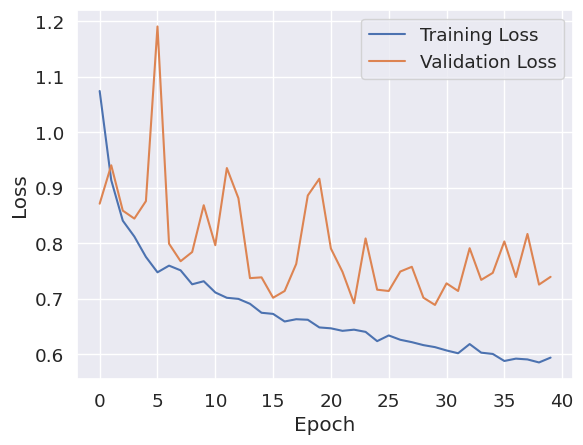

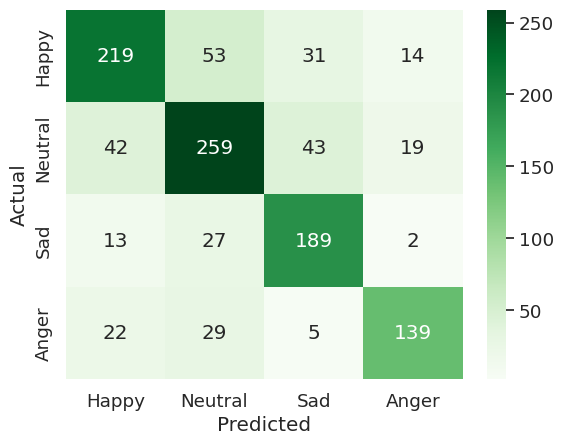

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6888145972782954 | U_Accuracy: 0.7338381721519089 | W_Accuracy: 0.72875226039783 | Precision: 0.7311941400632076 | Recall: 0.72875226039783 | f1: 0.728415408864377
Accuracy per class:
Class 0: 0.6908517350157729
Class 1: 0.7134986225895317
Class 2: 0.8181818181818182
Class 3: 0.7128205128205128


Epoch: 1 finished in 155.49 seconds, Training Loss:  1.07, Validation Loss: 1.05, Validation Accuracy:  0.56


Epoch: 2 finished in 155.53 seconds, Training Loss:  0.92, Validation Loss: 0.85, Validation Accuracy:  0.65


Epoch: 3 finished in 155.55 seconds, Training Loss:  0.84, Validation Loss: 0.82, Validation Accuracy:  0.68


...

Epoch: 36 finished in 155.54 seconds, Training Loss:  0.60, Validation Loss: 0.68, Validation Accuracy:  0.72


Epoch: 37 finished in 155.56 seconds, Training Loss:  0.59, Validation Loss: 0.78, Validation Accuracy:  0.69


Epoch: 38 finished in 155.57 seconds, Training Loss:  0.59, Validation Loss: 0.76, Validation Accuracy:  0.69


Epoch: 39 finished in 155.63 seconds, Training Loss:  0.59, Validation Loss: 0.72, Validation Accuracy:  0.71


Epoch: 40 finished in 155.64 seconds, Training Loss:  0.59, Validation Loss: 0.75, Validation Accuracy:  0.70
Each epoch took 155.54 seconds in average.


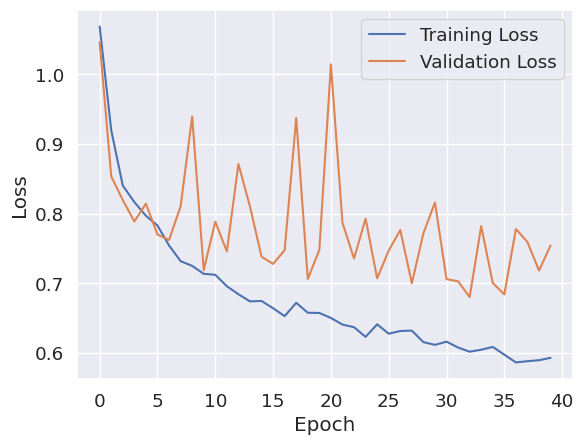

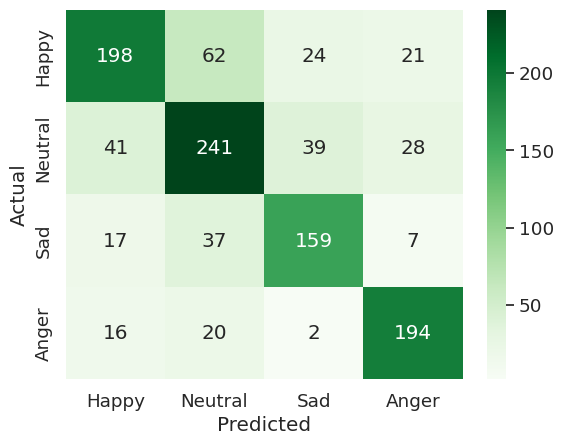

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6804641990481947 | U_Accuracy: 0.7246647274388248 | W_Accuracy: 0.7160940325497287 | Precision: 0.7159592081558362 | Recall: 0.7160940325497287 | f1: 0.7151064876125244
Accuracy per class:
Class 0: 0.6491803278688525
Class 1: 0.6905444126074498
Class 2: 0.7227272727272728
Class 3: 0.8362068965517241


Epoch: 1 finished in 155.36 seconds, Training Loss:  1.10, Validation Loss: 0.89, Validation Accuracy:  0.65


Epoch: 2 finished in 155.42 seconds, Training Loss:  0.91, Validation Loss: 1.11, Validation Accuracy:  0.52


Epoch: 3 finished in 155.43 seconds, Training Loss:  0.85, Validation Loss: 0.83, Validation Accuracy:  0.65


...

Epoch: 36 finished in 155.71 seconds, Training Loss:  0.59, Validation Loss: 0.90, Validation Accuracy:  0.65


Epoch: 37 finished in 155.73 seconds, Training Loss:  0.60, Validation Loss: 0.76, Validation Accuracy:  0.69


Epoch: 38 finished in 155.77 seconds, Training Loss:  0.59, Validation Loss: 0.71, Validation Accuracy:  0.71


Epoch: 39 finished in 155.77 seconds, Training Loss:  0.60, Validation Loss: 0.68, Validation Accuracy:  0.72


Epoch: 40 finished in 155.76 seconds, Training Loss:  0.58, Validation Loss: 0.70, Validation Accuracy:  0.71
Each epoch took 155.50 seconds in average.


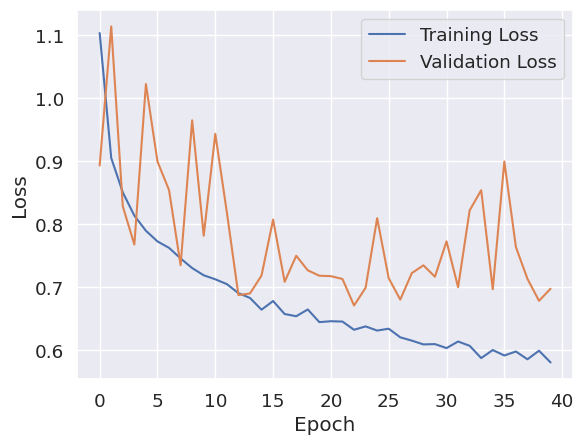

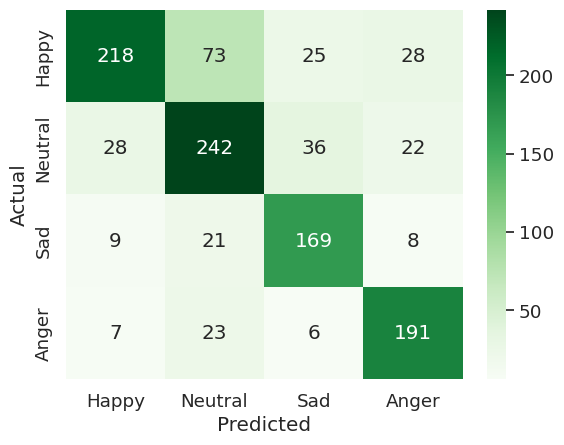

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6713155198822114 | U_Accuracy: 0.7573401551710603 | W_Accuracy: 0.7414104882459313 | Precision: 0.7501714471427358 | Recall: 0.7414104882459313 | f1: 0.7402237536610329
Accuracy per class:
Class 0: 0.6337209302325582
Class 1: 0.7378048780487805
Class 2: 0.8164251207729468
Class 3: 0.8414096916299559


Epoch: 1 finished in 155.81 seconds, Training Loss:  1.06, Validation Loss: 0.93, Validation Accuracy:  0.62


Epoch: 2 finished in 155.76 seconds, Training Loss:  0.92, Validation Loss: 0.85, Validation Accuracy:  0.64


Epoch: 3 finished in 155.76 seconds, Training Loss:  0.85, Validation Loss: 1.00, Validation Accuracy:  0.58


...

Epoch: 36 finished in 155.83 seconds, Training Loss:  0.59, Validation Loss: 0.81, Validation Accuracy:  0.69


Epoch: 37 finished in 155.83 seconds, Training Loss:  0.60, Validation Loss: 0.79, Validation Accuracy:  0.70


Epoch: 38 finished in 155.75 seconds, Training Loss:  0.58, Validation Loss: 0.70, Validation Accuracy:  0.73


Epoch: 39 finished in 155.83 seconds, Training Loss:  0.58, Validation Loss: 0.72, Validation Accuracy:  0.72


Epoch: 40 finished in 155.85 seconds, Training Loss:  0.59, Validation Loss: 0.79, Validation Accuracy:  0.69
Each epoch took 155.77 seconds in average.


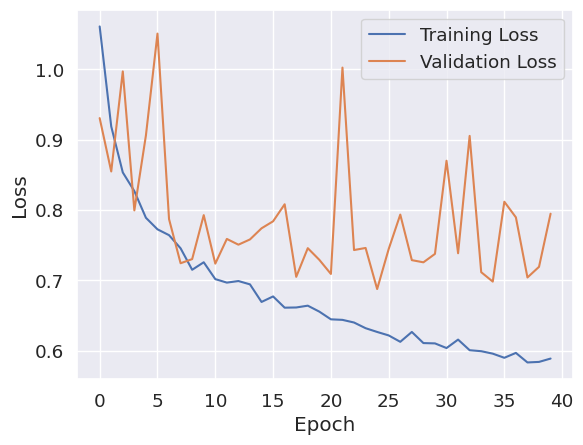

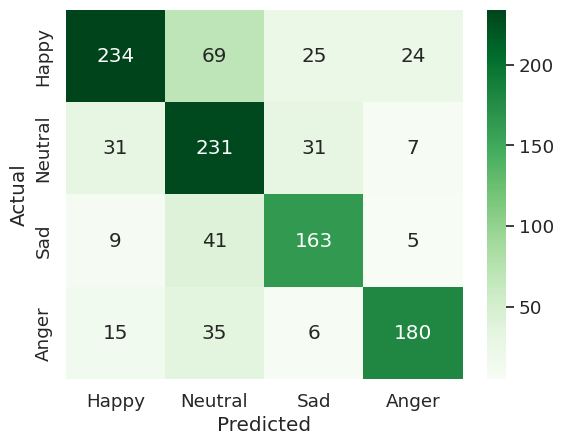

Testing finished with Loss: 0.6876339505389601 | U_Accuracy: 0.7362977534244639 | W_Accuracy: 0.7305605786618445 | Precision: 0.7449497710819989 | Recall: 0.7305605786618445 | f1: 0.7327459373768818
Accuracy per class:
Class 0: 0.6647727272727273
Class 1: 0.77
Class 2: 0.7477064220183486
Class 3: 0.7627118644067796


In [21]:
reset_seed(42)

for i, (train_loader, val_loader) in enumerate(loader_lists):
    whisper_tiny_path = 'whisper_small'
    whisper_tiny = WhisperForAudioClassification.from_pretrained(
        whisper_tiny_path
    )

    for param in whisper_tiny.parameters():
        param.requires_grad = False

    for param in whisper_tiny.projector.parameters():
        param.requires_grad = True

    whisper_tiny.classifier = torch.nn.Linear(256, 4) # Changing the head to fit our data and problem
    whisper_tiny.to(device)

    optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(whisper_tiny, f'iemo_whisper_small_shemo_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_tiny.load_state_dict(torch.load(f'iemo_whisper_small_shemo_simple_fold{i +1}.bin'))
    test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 465.79 seconds, Training Loss:  1.04, Validation Loss: 1.08, Validation Accuracy:  0.48


Epoch: 2 finished in 465.65 seconds, Training Loss:  0.85, Validation Loss: 0.77, Validation Accuracy:  0.69


Epoch: 3 finished in 465.52 seconds, Training Loss:  0.81, Validation Loss: 0.78, Validation Accuracy:  0.69


Epoch: 4 finished in 465.65 seconds, Training Loss:  0.78, Validation Loss: 0.73, Validation Accuracy:  0.70


...

Epoch: 36 finished in 465.58 seconds, Training Loss:  0.55, Validation Loss: 0.67, Validation Accuracy:  0.74


Epoch: 37 finished in 465.35 seconds, Training Loss:  0.55, Validation Loss: 0.69, Validation Accuracy:  0.73


Epoch: 38 finished in 465.40 seconds, Training Loss:  0.54, Validation Loss: 0.70, Validation Accuracy:  0.73


Epoch: 39 finished in 465.57 seconds, Training Loss:  0.53, Validation Loss: 0.66, Validation Accuracy:  0.74


Epoch: 40 finished in 465.56 seconds, Training Loss:  0.54, Validation Loss: 0.65, Validation Accuracy:  0.74
Each epoch took 465.59 seconds in average.


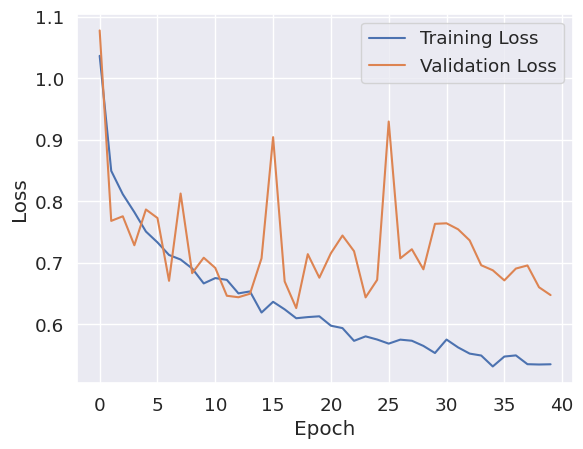

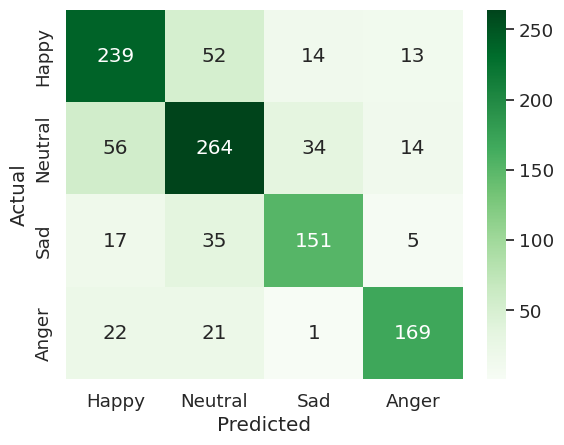

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6265946720770497 | U_Accuracy: 0.7470880999750845 | W_Accuracy: 0.7434507678410117 | Precision: 0.745114490302601 | Recall: 0.7434507678410117 | f1: 0.7439632134927637
Accuracy per class:
Class 0: 0.7515723270440252
Class 1: 0.717391304347826
Class 2: 0.7259615384615384
Class 3: 0.7934272300469484


Epoch: 1 finished in 465.57 seconds, Training Loss:  1.04, Validation Loss: 0.87, Validation Accuracy:  0.61


Epoch: 2 finished in 465.43 seconds, Training Loss:  0.86, Validation Loss: 0.80, Validation Accuracy:  0.68


Epoch: 3 finished in 465.57 seconds, Training Loss:  0.81, Validation Loss: 0.73, Validation Accuracy:  0.71


...

Epoch: 36 finished in 465.70 seconds, Training Loss:  0.54, Validation Loss: 0.73, Validation Accuracy:  0.74


Epoch: 37 finished in 465.75 seconds, Training Loss:  0.54, Validation Loss: 0.72, Validation Accuracy:  0.73


Epoch: 38 finished in 465.61 seconds, Training Loss:  0.55, Validation Loss: 0.97, Validation Accuracy:  0.66


Epoch: 39 finished in 465.83 seconds, Training Loss:  0.52, Validation Loss: 0.65, Validation Accuracy:  0.75


Epoch: 40 finished in 465.75 seconds, Training Loss:  0.52, Validation Loss: 0.68, Validation Accuracy:  0.74
Each epoch took 465.51 seconds in average.


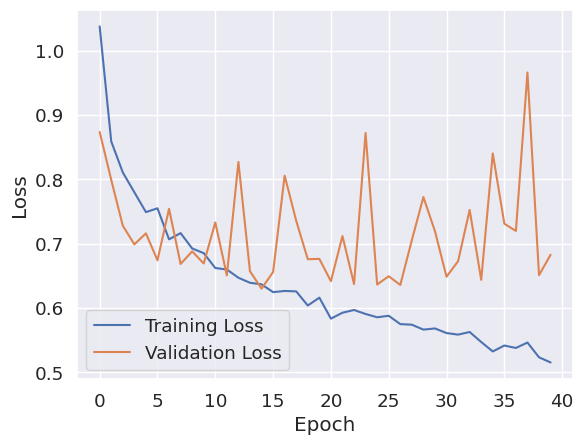

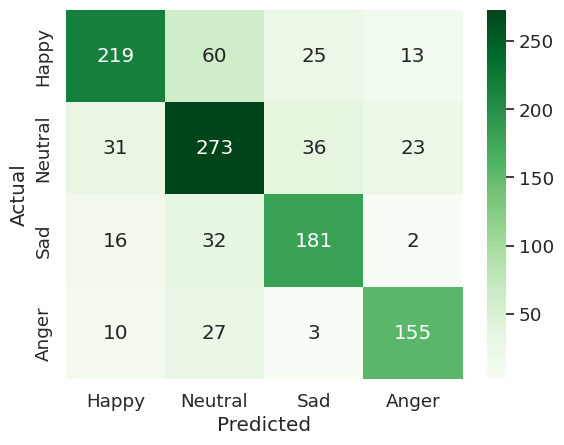

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6298935693228073 | U_Accuracy: 0.7553348572849576 | W_Accuracy: 0.7486437613019892 | Precision: 0.7518983188046535 | Recall: 0.7486437613019892 | f1: 0.7487622057495447
Accuracy per class:
Class 0: 0.6908517350157729
Class 1: 0.7520661157024794
Class 2: 0.7835497835497836
Class 3: 0.7948717948717948


Epoch: 1 finished in 465.65 seconds, Training Loss:  1.03, Validation Loss: 1.14, Validation Accuracy:  0.57


Epoch: 2 finished in 465.68 seconds, Training Loss:  0.86, Validation Loss: 0.84, Validation Accuracy:  0.65


Epoch: 3 finished in 465.68 seconds, Training Loss:  0.79, Validation Loss: 0.87, Validation Accuracy:  0.66


...

Epoch: 36 finished in 465.79 seconds, Training Loss:  0.53, Validation Loss: 0.79, Validation Accuracy:  0.70


Epoch: 37 finished in 466.04 seconds, Training Loss:  0.53, Validation Loss: 0.74, Validation Accuracy:  0.72


Epoch: 38 finished in 466.16 seconds, Training Loss:  0.53, Validation Loss: 0.71, Validation Accuracy:  0.72


Epoch: 39 finished in 465.95 seconds, Training Loss:  0.53, Validation Loss: 0.80, Validation Accuracy:  0.72


Epoch: 40 finished in 465.91 seconds, Training Loss:  0.54, Validation Loss: 0.80, Validation Accuracy:  0.71
Each epoch took 465.29 seconds in average.


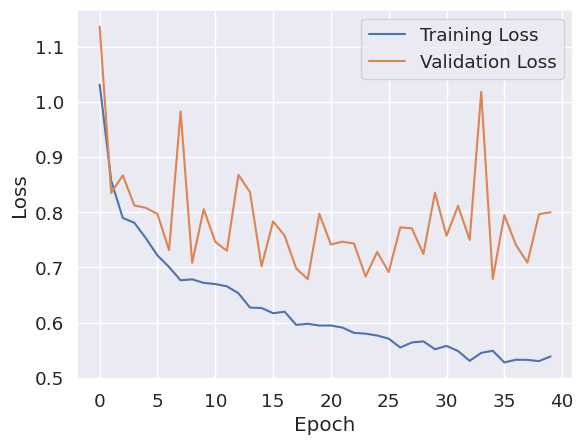

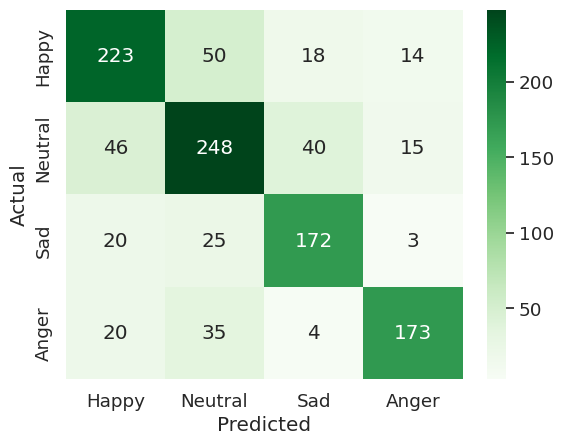

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6787069571466733 | U_Accuracy: 0.7423142742929775 | W_Accuracy: 0.7377938517179023 | Precision: 0.7408439415008735 | Recall: 0.7377938517179023 | f1: 0.7384946223178812
Accuracy per class:
Class 0: 0.7311475409836066
Class 1: 0.7106017191977078
Class 2: 0.7818181818181819
Class 3: 0.7456896551724138


Epoch: 1 finished in 466.08 seconds, Training Loss:  1.02, Validation Loss: 0.92, Validation Accuracy:  0.62


Epoch: 2 finished in 466.01 seconds, Training Loss:  0.86, Validation Loss: 0.95, Validation Accuracy:  0.62


Epoch: 3 finished in 466.08 seconds, Training Loss:  0.80, Validation Loss: 0.82, Validation Accuracy:  0.65


...

Epoch: 36 finished in 465.60 seconds, Training Loss:  0.54, Validation Loss: 0.65, Validation Accuracy:  0.74


Epoch: 37 finished in 465.65 seconds, Training Loss:  0.53, Validation Loss: 0.66, Validation Accuracy:  0.73


Epoch: 38 finished in 465.50 seconds, Training Loss:  0.54, Validation Loss: 0.69, Validation Accuracy:  0.74


Epoch: 39 finished in 465.36 seconds, Training Loss:  0.53, Validation Loss: 0.68, Validation Accuracy:  0.75


Epoch: 40 finished in 465.60 seconds, Training Loss:  0.53, Validation Loss: 0.77, Validation Accuracy:  0.70
Each epoch took 465.91 seconds in average.


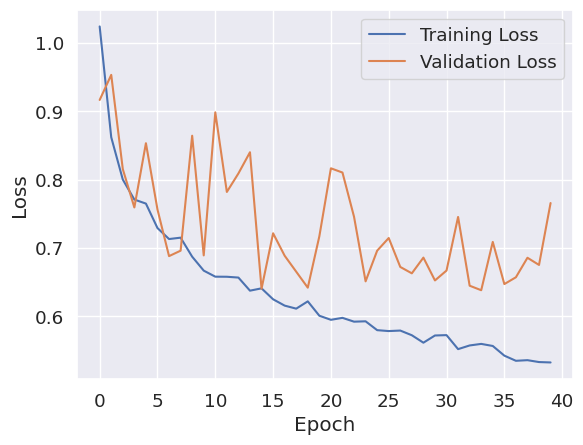

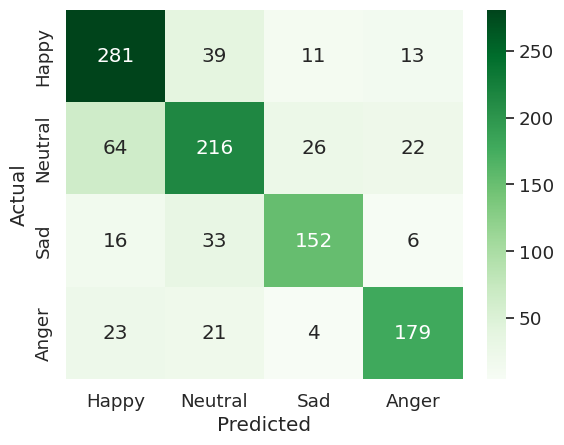

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_medium and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.6381816909604769 | U_Accuracy: 0.7495607057242384 | W_Accuracy: 0.7486437613019892 | Precision: 0.7493056793362846 | Recall: 0.7486437613019892 | f1: 0.7478537718883155
Accuracy per class:
Class 0: 0.8168604651162791
Class 1: 0.6585365853658537
Class 2: 0.7342995169082126
Class 3: 0.788546255506608


Epoch: 1 finished in 465.53 seconds, Training Loss:  1.05, Validation Loss: 0.81, Validation Accuracy:  0.69


Epoch: 2 finished in 465.63 seconds, Training Loss:  0.86, Validation Loss: 0.80, Validation Accuracy:  0.68


Epoch: 3 finished in 465.42 seconds, Training Loss:  0.81, Validation Loss: 0.80, Validation Accuracy:  0.68


...

Epoch: 36 finished in 466.39 seconds, Training Loss:  0.55, Validation Loss: 0.72, Validation Accuracy:  0.74


Epoch: 37 finished in 466.40 seconds, Training Loss:  0.54, Validation Loss: 0.65, Validation Accuracy:  0.76


Epoch: 38 finished in 466.40 seconds, Training Loss:  0.53, Validation Loss: 0.85, Validation Accuracy:  0.67


Epoch: 39 finished in 466.30 seconds, Training Loss:  0.53, Validation Loss: 0.83, Validation Accuracy:  0.68


Epoch: 40 finished in 466.36 seconds, Training Loss:  0.53, Validation Loss: 0.68, Validation Accuracy:  0.73
Each epoch took 466.12 seconds in average.


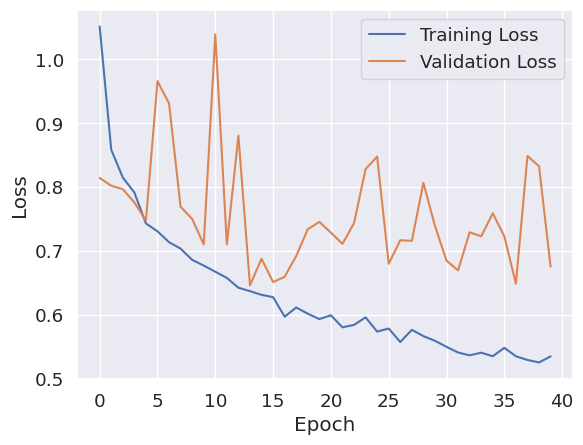

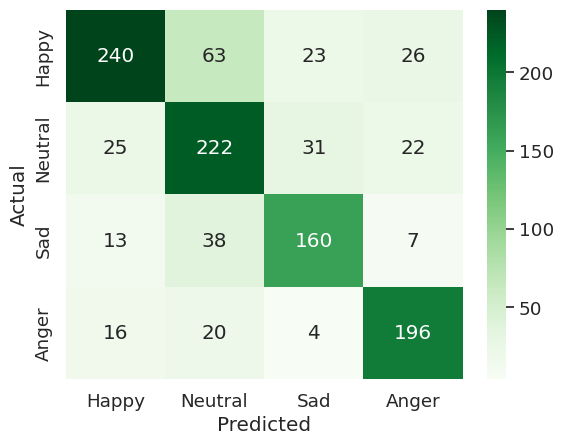

Testing finished with Loss: 0.6459990240673834 | U_Accuracy: 0.7465679026307234 | W_Accuracy: 0.7396021699819169 | Precision: 0.7466572220389368 | Recall: 0.7396021699819169 | f1: 0.7402034289474266
Accuracy per class:
Class 0: 0.6818181818181818
Class 1: 0.74
Class 2: 0.7339449541284404
Class 3: 0.8305084745762712


In [22]:
reset_seed(42)

for i, (train_loader, val_loader) in enumerate(loader_lists):
    whisper_tiny_path = 'whisper_medium'
    whisper_tiny = WhisperForAudioClassification.from_pretrained(
        whisper_tiny_path
    )

    for param in whisper_tiny.parameters():
        param.requires_grad = False

    for param in whisper_tiny.projector.parameters():
        param.requires_grad = True

    whisper_tiny.classifier = torch.nn.Linear(256, 4) # Changing the head to fit our data and problem
    whisper_tiny.to(device)

    optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(whisper_tiny, f'iemo_whisper_medium_shemo_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    whisper_tiny.load_state_dict(torch.load(f'iemo_whisper_medium_shemo_simple_fold{i +1}.bin'))
    test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)